# Datasets Combination

Merge all cleaned datasets into one

## A. Overview

List of datasets

- ACL_ICWSM_2018
- CrisisBench *(Combined)*
- CrisisLexT6
- CrisisLexT26
- CrisisMMD_V2
- CrisisNLP_R1
- Ecuador_Earthquake
- Eyewitness Messages
- HumAID
- ISCRAM2013
- SWDM2013

## B. Unified Dataset

### B.1. Merge

In [54]:
from pathlib import Path
# import os
import pandas as pd

import configuration
from src import dataset_settings

# from dotenv import load_dotenv
# load_dotenv()

all_files = [f for f in Path('datasets').rglob('*.csv') if f != Path('datasets/CrisisBench.csv')]
print(f"Found {len(all_files)} CSV files in the datasets directory.")
for f in all_files:
    print(f" - {f}")

df_sep = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

Found 10 CSV files in the datasets directory.
 - datasets/SWDM2013.csv
 - datasets/Ecuador_Earthquake_2016.csv
 - datasets/CrisisLexT6.csv
 - datasets/ISCRAM2013.csv
 - datasets/CrisisLexT26.csv
 - datasets/eyewitness_messages.csv
 - datasets/CrisisNLP.csv
 - datasets/ACL_ICWSM_2018.csv
 - datasets/HumAID.csv
 - datasets/CrisisMMD_v2.csv


In [55]:
df_sep['humanitarian_label'].unique()

array([nan, 'Casualties and damage', 'Information Source',
       'Caution and advice', 'Unknown',
       'Donations of money, goods or services', 'injured_or_dead_people',
       'other_useful_information', 'sympathy_and_emotional_support',
       'infrastructure_and_utilities_damage',
       'donation_needs_or_offers_or_volunteering_services',
       'caution_and_advice', 'displaced_people_and_evacuations',
       'missing_trapped_or_found_people', 'not_related_or_irrelevant',
       'Information source', 'People missing, found or seen',
       'rescue_volunteering_or_donation_effort', 'sympathy_and_support',
       'infrastructure_and_utility_damage', 'other_relevant_information',
       'not_humanitarian', 'requests_or_urgent_needs',
       'missing_or_found_people', 'affected_individuals', 'unclassified'],
      dtype=object)

### CrisisBench

The CrisisBench dataset combines
- CrisisLex
- CrisisNLP
- SWDM13
- ISCRAM13
- DRD
- DSM
- CrisisMMD
- AIDR

The author did some cleaning and mapping, then we remove them to keep original tweet text.

In [56]:
df_cb = pd.read_csv('datasets/CrisisBench.csv')

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_62459/2814787164.py:1: DtypeWarning: Columns (5,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cb = pd.read_csv('datasets/CrisisBench.csv')


In [57]:
print(f"df_cb: {len(df_cb)} rows")
print(f"df_sep: {len(df_sep)} rows")

df_cb: 151999 rows
df_sep: 224984 rows


In [58]:
include_datasets = [
    "DRD-FigureEight-Multimedia",
    "AIDR_system",
    # these datasets have been edited, use the original ones instead
    # "CrisisLexT26",
    # "CrisisLexT6",
    # "CrisisNLP-volunteers",
    # "CrisisNLP-CF",
    # "SWDM13",
    # "ISCRAM13",
    # "DSM-CF",
    # "CrisisMMD",
]
df_cb_unq_ids = df_cb[df_cb["dataset"].isin(include_datasets)]['tweet_id']

In [59]:
len(df_cb_unq_ids)

28835

In [60]:
# print(df.duplicated(subset=['tweet_id']).sum())
# print(df.duplicated(subset=['tweet_text']).sum())

# df = df[~df['tweet_id'].isin(df_cb['tweet_id'])]
# df = df[~df['tweet_text'].isin(df_cb['tweet_text'])]
df = pd.concat([df_sep, df_cb[df_cb['tweet_id'].isin(df_cb_unq_ids)]], ignore_index=True)
# df = pd.concat([df, df_cb], ignore_index=True)

# df['tweet_id'] = df['tweet_id'].astype(str)

In [61]:
print(f"df: {len(df)} rows")

df: 253819 rows


### B.2. Remove Duplicated

In [62]:
df_dup_id = df[df.duplicated(subset=['tweet_id'], keep=False)]
print(f"Number of duplicate tweet_ids: {len(df_dup_id)}")

df_dup_text = df[df.duplicated(subset=['tweet_text'], keep=False)]
print(f"Number of duplicate tweet_texts: {len(df_dup_text)}")

Number of duplicate tweet_ids: 34995
Number of duplicate tweet_texts: 36931


In [63]:
set(df_dup_id['tweet_id']).issubset(set(df_dup_text['tweet_id']))

False

In [64]:
df = df.drop_duplicates(subset=['tweet_id']).drop_duplicates(subset=['tweet_text'])
print(f"df: {len(df)} rows")

df: 233847 rows


### B.3. Re-order columns

In [65]:
df = df[['tweet_id', 'tweet_text', 'relevant', 'humanitarian_label', 'dataset',
         'event_type', 'year', 'event_name', 'country', 'url', 'original_relevant_label', 'original_humanitarian_label', 'meta']]

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233847 entries, 0 to 253818
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   tweet_id                     233847 non-null  object 
 1   tweet_text                   233847 non-null  object 
 2   relevant                     233847 non-null  bool   
 3   humanitarian_label           156175 non-null  object 
 4   dataset                      233847 non-null  object 
 5   event_type                   233847 non-null  object 
 6   year                         205036 non-null  float64
 7   event_name                   220023 non-null  object 
 8   country                      41506 non-null   object 
 9   url                          4173 non-null    object 
 10  original_relevant_label      92237 non-null   object 
 11  original_humanitarian_label  152002 non-null  object 
 12  meta                         200913 non-null  object 
dtypes: b

In [67]:
df.head()

,tweet_id,tweet_text,relevant,humanitarian_label,dataset,event_type,year,event_name,country,url,original_relevant_label,original_humanitarian_label,meta
0,999128355989445507485,RT @NASA: Watch Hurricane #Sandy prowling the ...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
1,999854949519964969681,RT @cnnbrk: President Obama declares states of...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
2,999282341088111907415,WOW scary! RT @Zamba4: That's haunting!. Flood...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
3,999160876273137374942,RT @twc_hurricane: RT @nowthised: Wider shot o...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
4,999118168890076913833,Going to be replacing some fence when the stor...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN


## C. Humanitarian Label Mapping

In [68]:
print(df['humanitarian_label'].unique())

[nan 'Casualties and damage' 'Unknown' 'Caution and advice'
 'Donations of money, goods or services' 'Information Source'
 'injured_or_dead_people' 'other_useful_information'
 'sympathy_and_emotional_support' 'infrastructure_and_utilities_damage'
 'donation_needs_or_offers_or_volunteering_services' 'caution_and_advice'
 'displaced_people_and_evacuations' 'missing_trapped_or_found_people'
 'not_related_or_irrelevant' 'Information source'
 'People missing, found or seen' 'rescue_volunteering_or_donation_effort'
 'sympathy_and_support' 'infrastructure_and_utility_damage'
 'other_relevant_information' 'not_humanitarian'
 'requests_or_urgent_needs' 'missing_or_found_people'
 'affected_individuals' 'unclassified' 'requests_or_needs'
 'affected_individual' 'donation_and_volunteering'
 'missing_and_found_people' 'displaced_and_evacuations']


In [69]:
# map the humanitarian labels to the unified set of labels
df['humanitarian_label'] = df['humanitarian_label'].map(dataset_settings.humanitarian_labels_mapping)
print(df['humanitarian_label'].unique())

[nan 'injured_or_dead_people' 'unknown_or_unclassified'
 'rescue_volunteering_or_donation_effort' 'other_relevant_information'
 'sympathy_and_support' 'infrastructure_and_utility_damage'
 'displaced_people_and_evacuations' 'missing_trapped_or_found_people'
 'not_related_or_irrelevant' 'not_humanitarian' 'requests_or_needs'
 'affected_individuals']


# D. Review

<Axes: xlabel='dataset'>

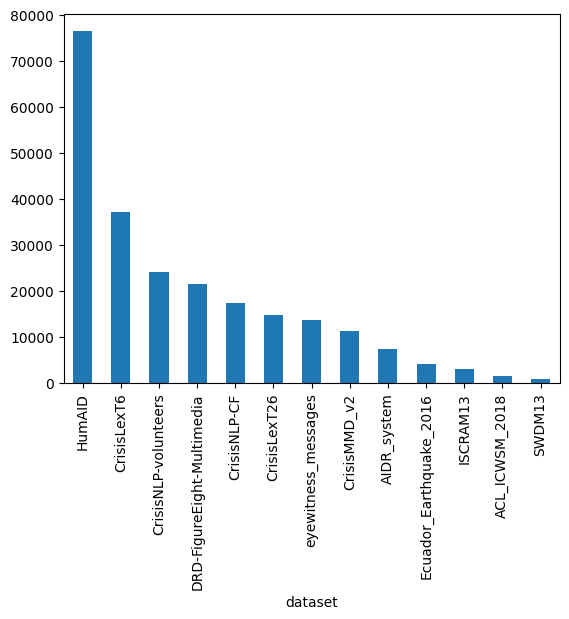

In [70]:
df['dataset'].value_counts().plot(kind='bar')

<Axes: xlabel='humanitarian_label'>

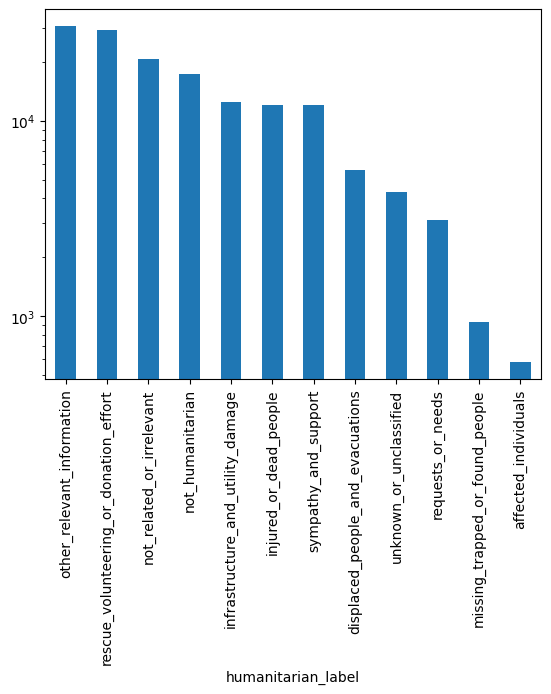

In [71]:
df['humanitarian_label'].value_counts().plot(kind='bar', logy=True)

Text(0.5, 1.0, 'Number of event_name entries for each event_type')

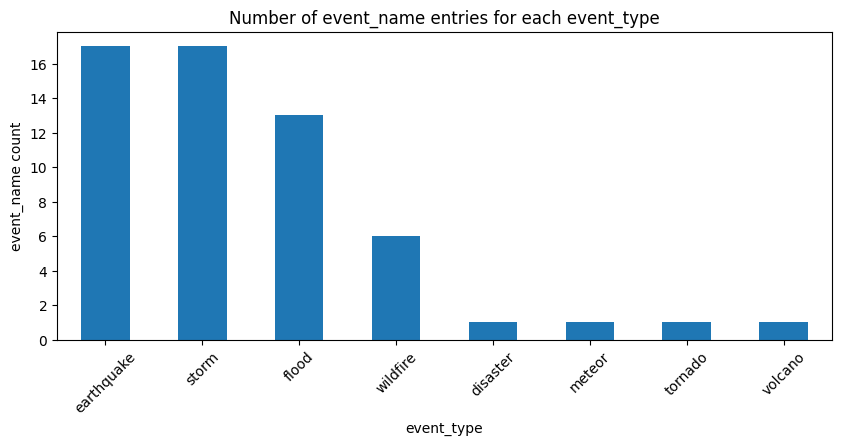

In [72]:
event_name_count_by_type = (
    df.groupby('event_type')['event_name']
      .nunique()
      .sort_values(ascending=False)
)

ax = event_name_count_by_type.plot(kind='bar', figsize=(10, 4), rot=45)
ax.set_xlabel('event_type')
ax.set_ylabel('event_name count')
ax.set_title('Number of event_name entries for each event_type')

In [73]:
event_name_count_by_type.head(10)

event_type
earthquake    17
storm         17
flood         13
wildfire       6
disaster       1
meteor         1
tornado        1
volcano        1
Name: event_name, dtype: int64

<Axes: xlabel='relevant'>

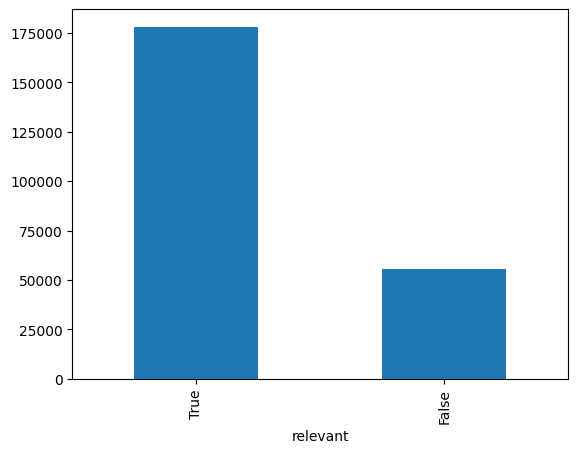

In [74]:
df['relevant'].value_counts().plot(kind='bar')

# E. Normalize

### E.1. emoji

In [79]:
%pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 5.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import emoji

emoji_cnt = 0
cnt = 0

# # Count emojis in each tweet and sum them up to know if this step is worth
# for text in df['tweet_text']:
#     cnt += 1
#     emoji_cnt += len(emoji.emoji_list(text))
#     if cnt % 10000 == 0:
#         print(f"Processed {cnt} tweets, current total emoji count: {emoji_cnt}")
    
# print(f"Total number of emojis in the dataset: {emoji_cnt}")
# # Total number of emojis in the dataset: 7069

# demojize the tweets and check if there are duplicates after demojization
# print(emoji.demojize('Python is 👍')) # => `Python is :thumbs_up:`
df['tweet_text'] = df['tweet_text'].apply(emoji.demojize)

### E.2. mentions and web/url links

### E.3. mentions and web/url links

In [ ]:
import unicodedata

def remove_control_characters(text):
    """
    Removes Unicode control (Cc) and format (Cf) characters.
    Commonly used to clean 'invisible' noise from scraped or tweet data.
    """
    return "".join(
        ch for ch in text 
        if unicodedata.category(ch)[0] != "C"
    )

In [75]:
import csv

df.to_csv('data/unified_dataset.csv', index=False, quoting=csv.QUOTE_ALL)

In [76]:
df.head()

,tweet_id,tweet_text,relevant,humanitarian_label,dataset,event_type,year,event_name,country,url,original_relevant_label,original_humanitarian_label,meta
0,999128355989445507485,RT @NASA: Watch Hurricane #Sandy prowling the ...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
1,999854949519964969681,RT @cnnbrk: President Obama declares states of...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
2,999282341088111907415,WOW scary! RT @Zamba4: That's haunting!. Flood...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
3,999160876273137374942,RT @twc_hurricane: RT @nowthised: Wider shot o...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
4,999118168890076913833,Going to be replacing some fence when the stor...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN


In [77]:
df_relevant = df[['tweet_text', 'relevant']]
df_relevant.to_csv('data/unified_relevant_dataset.csv',quoting=csv.QUOTE_ALL)

df_humanitarian = df[~df['humanitarian_label'].isnull()][['tweet_text', 'humanitarian_label']]
df_humanitarian.to_csv('data/unified_humanitarian_dataset.csv',quoting=csv.QUOTE_ALL)